# Notebook 16 — Reference-Free VoxIntel-R Risk Prediction

**Notebook 16 is the first leakage-free VoxIntel-R experiment.** It intentionally
uses only inference-time ASR and intent signals and excludes reference
transcripts, WER/CER, taxonomy features, N-best decoding, and language-model
rescoring from the MVP.

Success criterion: **first establish whether ASR-native + intent-native
uncertainty beats the existing flat-confidence baselines. Only then decide
whether N-best/LM infrastructure is worth building.**

| Notebook | Purpose |
|---|---|
| 15 | Reference-dependent semantic error risk analysis (has ground-truth leakage) |
| **16** | **Reference-free VoxIntel-R risk prediction (this notebook)** |


## 0. Research Contract

### Research question (RQ2)
> Can inference-time ASR and intent uncertainty predict downstream intent
> failure **without access to the reference transcript**?

### Hypothesis (H1)
> Reference-free ASR/intent uncertainty provides predictive signal for
> downstream intent failure and can outperform simple single-confidence
> baselines (ASR-confidence-only, intent-confidence-only).

### Leakage rule — read before writing any feature code

**Allowed as inference-time features:**
- audio waveform / duration
- ASR logits, ASR softmax probabilities
- the ASR model's own decoded transcript
- intent-model probabilities / logits over the ASR transcript

**Never allowed as features (this is what broke Notebook 15):**
- the ground-truth transcript
- the baseline (non-fine-tuned) ASR transcript
- WER / CER / edit distance to any reference
- lexical overlap with the reference
- taxonomy categories derived from reference alignment
- the semantic impact matrix from Notebooks 09–14

**Ground truth is allowed for exactly one purpose:** computing the
evaluation *target* (`intent_failed = predicted_intent != ground_truth_intent`).
It must never enter the feature matrix `X`.

This notebook explicitly does **not**:
- retrain Wav2Vec2 or DistilBERT
- compute WER/CER as a feature
- align against reference transcripts
- use taxonomy categories or the semantic impact matrix
- implement N-best decoding or KenLM/LM rescoring (see Section 17 — deferred)
- attempt calibration or cost-sensitive optimization (that's Notebooks 17–18)


## 1. Setup & Reproducibility

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: c:\Users\ACER\OneDrive\Desktop\VoxIntel


In [2]:
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from IPython.display import display

from transformers import AutoTokenizer, DistilBertForSequenceClassification

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    brier_score_loss,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


c:\Users\ACER\anaconda3\envs\torch26\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
CONFIG = {
    "RANDOM_STATE": 42,
    "N_SPLITS": 5,                                          # StratifiedKFold for cross-validated evaluation
    "MAX_SAMPLES": None,                                    # set an int for a quick smoke-test run, None = full eval population
    "CHECKPOINT_EVERY": 250,                                # rows between partial-feature-table saves (resumable on crash)
    "DECISION_THRESHOLD": 0.5,                              # provisional only — real threshold selection happens in Notebook 17
    "SPLIT_COLUMN_CANDIDATES": ["split", "subset", "partition"],
    "SPLIT_VALUE_CANDIDATES": ["val", "validation", "dev", "test"],
    "INTENT_COLUMN_CANDIDATES": ["intent", "ground_truth_intent", "label"],
    "SCENARIO_COLUMN_CANDIDATES": ["scenario"],
    "AUDIO_COLUMN_CANDIDATES": ["audio_path", "audio_filepath", "path"],
}

random.seed(CONFIG["RANDOM_STATE"])
np.random.seed(CONFIG["RANDOM_STATE"])
torch.manual_seed(CONFIG["RANDOM_STATE"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))


Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM (GB): 4.29


> **Signature note — adapt this cell if your `src/` package differs.**
> This notebook assumes the same helper signatures used in Notebooks 03–08:
> `load_asr_model(checkpoint_dir) -> (processor, model, device)` from
> `src.asr.inference`, and `load_audio(path) -> (waveform, sample_rate)` from
> `src.utils.audio`. If your actual functions return things in a different
> order or shape, fix only the two thin wrapper calls in Section 2/4 — the
> rest of the notebook doesn't care how those functions are implemented
> internally.


## 2. Load Existing Models

Reuses the fine-tuned ASR checkpoint from Notebook 06 and the intent model
from Notebook 08. Nothing is retrained here.


In [4]:
CHECKPOINT_DIR = PROJECT_ROOT / "models" / "wav2vec2_slurp_debug" / "checkpoint-46500"
MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / "distilbert_intent"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
REPORTS_DIR = PROJECT_ROOT / "reports"
MASTER_TRANSCRIPTS_PATH = REPORTS_DIR / "master_transcripts.csv"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

for p, name in [
    (CHECKPOINT_DIR, "ASR checkpoint"),
    (MODEL_OUTPUT_DIR, "Intent model dir"),
    (MASTER_TRANSCRIPTS_PATH, "master_transcripts.csv"),
]:
    status = "FOUND" if p.exists() else "MISSING — check path before continuing"
    print(f"[{status}] {name}: {p}")


[FOUND] ASR checkpoint: c:\Users\ACER\OneDrive\Desktop\VoxIntel\models\wav2vec2_slurp_debug\checkpoint-46500
[FOUND] Intent model dir: c:\Users\ACER\OneDrive\Desktop\VoxIntel\models\distilbert_intent
[FOUND] master_transcripts.csv: c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\master_transcripts.csv


In [5]:
# --- ASR model -------------------------------------------------------
from src.asr.inference import load_asr_model

processor, asr_model, asr_device = load_asr_model(str(CHECKPOINT_DIR))
asr_model = asr_model.to(device)
asr_model.eval()

print("ASR model loaded from:", CHECKPOINT_DIR)
print("ASR vocab size:", asr_model.config.vocab_size)


Loading weights: 100%|██████████| 213/213 [00:00<00:00, 255.01it/s, Materializing param=wav2vec2.masked_spec_embed]                                            


ASR model loaded from: c:\Users\ACER\OneDrive\Desktop\VoxIntel\models\wav2vec2_slurp_debug\checkpoint-46500
ASR vocab size: 32


In [6]:
# --- Intent model ------------------------------------------------------
# Loaded directly with transformers rather than a custom src.intent module,
# since the exact API surface of src/intent/model.py wasn't available while
# building this notebook. If your project already exposes a loader there,
# swap this cell for that call — everything downstream only needs
# `tokenizer`, `intent_model`, and `id2label`.

tokenizer = AutoTokenizer.from_pretrained(str(MODEL_OUTPUT_DIR))
intent_model = DistilBertForSequenceClassification.from_pretrained(str(MODEL_OUTPUT_DIR))
intent_model = intent_model.to(device)
intent_model.eval()

id2label = intent_model.config.id2label
label2id = intent_model.config.label2id

print("Intent model loaded from:", MODEL_OUTPUT_DIR)
print("Number of intent classes:", len(id2label))


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 223.62it/s, Materializing param=pre_classifier.weight]                                  


Intent model loaded from: c:\Users\ACER\OneDrive\Desktop\VoxIntel\models\distilbert_intent
Number of intent classes: 91


## 3. Load Evaluation Population

We reuse **only** the audio path, the ground-truth intent label, and the
scenario/split columns from `master_transcripts.csv`. Every other column
(`ground_truth` transcript, `baseline_transcript`, historical `confidence`,
etc.) is dropped immediately — this notebook recomputes everything itself
from the current checkpoints so it stays self-contained and reproducible,
and so nothing reference-derived accidentally survives into the feature
table.


In [7]:
df_raw = pd.read_csv(MASTER_TRANSCRIPTS_PATH)
print("Columns in master_transcripts.csv:", df_raw.columns.tolist())
print("Rows:", len(df_raw))
display(df_raw.head(3))


Columns in master_transcripts.csv: ['audio_path', 'ground_truth', 'baseline_transcript', 'finetuned_transcript', 'intent', 'scenario', 'confidence', 'latency_ms']
Rows: 8690


,audio_path,ground_truth,baseline_transcript,finetuned_transcript,intent,scenario,confidence,latency_ms
0,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN,qa_currency,qa,0.966625,27.5224
1,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN,qa_currency,qa,0.944935,27.0343
2,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,email,0.988258,29.6696


In [8]:
def _find_column(df, candidates, required=True, label=""):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Could not find a {label} column among {candidates}. "
                        f"Available columns: {df.columns.tolist()}")
    return None

audio_col = _find_column(df_raw, CONFIG["AUDIO_COLUMN_CANDIDATES"], label="audio path")
intent_col = _find_column(df_raw, CONFIG["INTENT_COLUMN_CANDIDATES"], label="ground-truth intent")
scenario_col = _find_column(df_raw, CONFIG["SCENARIO_COLUMN_CANDIDATES"], required=False, label="scenario")
split_col = _find_column(df_raw, CONFIG["SPLIT_COLUMN_CANDIDATES"], required=False, label="split")

keep_cols = [c for c in [audio_col, intent_col, scenario_col, split_col] if c is not None]
df_eval = df_raw[keep_cols].copy()
df_eval = df_eval.rename(columns={audio_col: "audio_path", intent_col: "ground_truth_intent"})
if scenario_col is not None:
    df_eval = df_eval.rename(columns={scenario_col: "scenario"})
if split_col is not None:
    df_eval = df_eval.rename(columns={split_col: "split"})

dropped = [c for c in df_raw.columns if c not in keep_cols]
print("Columns kept for the evaluation population (reference-safe):", df_eval.columns.tolist())
print("Columns dropped (may contain reference-derived info, not used downstream):", dropped)


Columns kept for the evaluation population (reference-safe): ['audio_path', 'ground_truth_intent', 'scenario']
Columns dropped (may contain reference-derived info, not used downstream): ['ground_truth', 'baseline_transcript', 'finetuned_transcript', 'confidence', 'latency_ms']


In [9]:
# Restrict to a validation/dev/test split if the file has one.
if "split" in df_eval.columns:
    available_splits = df_eval["split"].unique().tolist()
    print("Available split values:", available_splits)
    chosen = next((s for s in CONFIG["SPLIT_VALUE_CANDIDATES"] if s in available_splits), None)
    if chosen is not None:
        df_eval = df_eval[df_eval["split"] == chosen].reset_index(drop=True)
        print(f"Filtered to split == '{chosen}' -> {len(df_eval)} rows")
    else:
        print("No recognized val/test split value found — using the full file. "
              "Adjust CONFIG['SPLIT_VALUE_CANDIDATES'] if your split labels differ.")
else:
    print("No split column found — using the full file as the evaluation population. "
          "If master_transcripts.csv mixes train/val, filter df_eval manually here "
          "to match the ~2,032-example validation population used in Notebook 07.")

# Drop intents the classifier was never trained on (mirrors the known
# 101-vs-91-class gap documented in the Notebook 07 audit).
known_intents = set(id2label.values())
before = len(df_eval)
df_eval = df_eval[df_eval["ground_truth_intent"].isin(known_intents)].reset_index(drop=True)
print(f"Dropped {before - len(df_eval)} rows with intents unseen by the classifier "
      f"(e.g. 'likeness') -> {len(df_eval)} rows remain")

if CONFIG["MAX_SAMPLES"] is not None:
    df_eval = df_eval.sample(n=min(CONFIG["MAX_SAMPLES"], len(df_eval)),
                              random_state=CONFIG["RANDOM_STATE"]).reset_index(drop=True)
    print(f"MAX_SAMPLES set — using {len(df_eval)} rows for a smoke test")

df_eval["ground_truth_intent"].value_counts().head(10)


No split column found — using the full file as the evaluation population. If master_transcripts.csv mixes train/val, filter df_eval manually here to match the ~2,032-example validation population used in Notebook 07.
Dropped 2 rows with intents unseen by the classifier (e.g. 'likeness') -> 8688 rows remain


ground_truth_intent
play_music        503
weather_query     474
calendar_set      463
calendar_query    454
general_quirky    438
qa_factoid        332
datetime_query    308
news_query        306
email_query       282
play_audiobook    279
Name: count, dtype: int64

## 4. ASR-Native Feature Extraction

Everything here comes from the fine-tuned Wav2Vec2 model's own output
distribution for the given audio. Nothing here touches a reference
transcript.


In [10]:
def load_waveform(audio_path: str):
    """Thin wrapper around the project's existing audio loader.

    Assumed signature: load_audio(path) -> (waveform: np.ndarray, sample_rate: int)
    Adjust the unpacking below if your src.utils.audio.load_audio differs.
    """
    from src.utils.audio import load_audio
    waveform, sample_rate = load_audio(str(audio_path))
    return waveform, sample_rate


@torch.no_grad()
def get_asr_logits(waveform, sample_rate):
    """Forward pass only — returns raw (T, V) logits, kept on CPU."""
    inputs = processor(waveform, sampling_rate=sample_rate, return_tensors="pt", padding=True)
    input_values = inputs["input_values"].to(device)
    attention_mask = inputs.get("attention_mask")
    if attention_mask is not None:
        attention_mask = attention_mask.to(device)
        logits = asr_model(input_values, attention_mask=attention_mask).logits
    else:
        logits = asr_model(input_values).logits
    return logits.squeeze(0).detach().cpu()  # (T, V)


def ctc_decode(logits: torch.Tensor) -> str:
    """Greedy CTC decode — the MVP intentionally does not use beam search
    or an N-best list (see Section 17)."""
    predicted_ids = torch.argmax(logits, dim=-1).unsqueeze(0)
    transcript = processor.batch_decode(predicted_ids)[0]
    return transcript.strip()


def extract_asr_features(logits: torch.Tensor) -> dict:
    """Reference-free by construction: derived only from the ASR model's
    own output distribution for this utterance."""
    probs = F.softmax(logits, dim=-1)                 # (T, V)
    max_probs = probs.max(dim=-1).values               # (T,)
    eps = 1e-10
    entropy = -(probs * (probs + eps).log()).sum(dim=-1)  # (T,)

    max_probs_np = max_probs.numpy()
    entropy_np = entropy.numpy()

    return {
        "asr_mean_confidence": float(np.mean(max_probs_np)),
        "asr_min_confidence": float(np.min(max_probs_np)),
        "asr_std_confidence": float(np.std(max_probs_np)),
        "asr_median_confidence": float(np.median(max_probs_np)),
        "asr_mean_entropy": float(np.mean(entropy_np)),
        "asr_max_entropy": float(np.max(entropy_np)),
        "asr_std_entropy": float(np.std(entropy_np)),
        "asr_num_frames": int(logits.shape[0]),
    }


def extract_audio_features(waveform, sample_rate) -> dict:
    duration = len(waveform) / float(sample_rate)
    return {"audio_duration": float(duration)}


## 5. Intent-Native Feature Extraction

Everything here comes from DistilBERT's own predictive distribution over
the **ASR-produced transcript** (not the reference transcript).


In [11]:
@torch.no_grad()
def get_intent_probs(transcript: str) -> np.ndarray:
    inputs = tokenizer(transcript, return_tensors="pt", truncation=True, padding=True).to(device)
    logits = intent_model(**inputs).logits
    probs = F.softmax(logits, dim=-1).squeeze(0).detach().cpu().numpy()
    return probs


def extract_intent_features(intent_probs: np.ndarray) -> dict:
    """Reference-free: derived only from the intent model's own predictive
    distribution over the ASR transcript."""
    sorted_probs = np.sort(intent_probs)[::-1]
    top1 = float(sorted_probs[0])
    top2 = float(sorted_probs[1]) if len(sorted_probs) > 1 else 0.0
    eps = 1e-10
    entropy = float(-np.sum(intent_probs * np.log(intent_probs + eps)))

    return {
        "intent_confidence": top1,
        "intent_entropy": entropy,
        "intent_margin": top1 - top2,
    }


## 6. Construct Failure Target

Ground truth is used **only** here, to compute the label the risk model is
trained to predict — never as a feature.


In [12]:
def compute_failure_target(predicted_intent: str, ground_truth_intent: str) -> int:
    return int(predicted_intent != ground_truth_intent)


## 7. Leakage Audit

Declared once, checked twice: once here against the *planned* schema, and
again in Section 8 against the *actual* feature table after it's built.
This is the single most important cell in the notebook — Notebook 15's
central methodological failure was exactly this kind of leakage.


In [13]:
FORBIDDEN_FEATURES = {
    "ground_truth", "ground_truth_transcript", "reference_transcript",
    "baseline_transcript", "wer", "cer", "reference_overlap",
    "lexical_overlap", "edit_distance", "semantic_error_type",
    "taxonomy_category", "error_category", "semantic_impact",
}

PLANNED_FEATURE_COLUMNS = [
    # ASR-native
    "asr_mean_confidence", "asr_min_confidence", "asr_std_confidence",
    "asr_median_confidence", "asr_mean_entropy", "asr_max_entropy",
    "asr_std_entropy", "asr_num_frames",
    # audio-native
    "audio_duration",
    # intent-native
    "intent_confidence", "intent_entropy", "intent_margin",
]

def leakage_check(feature_columns, label=""):
    hits = [f for f in feature_columns if f.lower() in FORBIDDEN_FEATURES]
    print(f"REFERENCE-TRANSCRIPT LEAKAGE CHECK ({label})")
    print("-" * 45)
    if hits:
        raise AssertionError(f"Forbidden reference-derived feature(s) found: {hits}")
    for forbidden in sorted(FORBIDDEN_FEATURES):
        print(f"{forbidden:25s}: NOT USED")
    print("PASS\n")

leakage_check(PLANNED_FEATURE_COLUMNS, label="planned schema")


REFERENCE-TRANSCRIPT LEAKAGE CHECK (planned schema)
---------------------------------------------
baseline_transcript      : NOT USED
cer                      : NOT USED
edit_distance            : NOT USED
error_category           : NOT USED
ground_truth             : NOT USED
ground_truth_transcript  : NOT USED
lexical_overlap          : NOT USED
reference_overlap        : NOT USED
reference_transcript     : NOT USED
semantic_error_type      : NOT USED
semantic_impact          : NOT USED
taxonomy_category        : NOT USED
wer                      : NOT USED
PASS



## 8. Build Reference-Free Feature Table

Single pass over the evaluation population. Checkpoints partial progress
every `CONFIG["CHECKPOINT_EVERY"]` rows so a crash (RTX 3050, 4.29 GB VRAM)
doesn't cost a full rerun — matches the checkpoint-based training pattern
already used in Notebook 05.


In [14]:
PARTIAL_PATH = REPORTS_DIR / "voxintel_r_features_partial.csv"
FINAL_PATH = REPORTS_DIR / "voxintel_r_features.csv"

already_done = set()
partial_rows = []
if PARTIAL_PATH.exists():
    partial_df = pd.read_csv(PARTIAL_PATH)
    partial_rows = partial_df.to_dict("records")
    already_done = set(partial_df["audio_path"].tolist())
    print(f"Resuming — {len(already_done)} rows already processed in a previous run.")

failed_rows = []
rows = partial_rows

for i, row in enumerate(tqdm(df_eval.itertuples(index=False), total=len(df_eval), desc="Extracting features")):
    audio_path = getattr(row, "audio_path")
    if audio_path in already_done:
        continue

    try:
        waveform, sample_rate = load_waveform(audio_path)

        logits = get_asr_logits(waveform, sample_rate)
        transcript = ctc_decode(logits)
        asr_feats = extract_asr_features(logits)
        audio_feats = extract_audio_features(waveform, sample_rate)

        intent_probs = get_intent_probs(transcript)
        pred_id = int(np.argmax(intent_probs))
        predicted_intent = id2label[pred_id]
        intent_feats = extract_intent_features(intent_probs)

        ground_truth_intent = getattr(row, "ground_truth_intent")
        target = compute_failure_target(predicted_intent, ground_truth_intent)

        record = {
            "audio_path": audio_path,
            "scenario": getattr(row, "scenario", None) if hasattr(row, "scenario") else None,
            "ground_truth_intent": ground_truth_intent,
            "predicted_intent": predicted_intent,
            "asr_transcript": transcript,   # kept for failure-case inspection only, not a feature
            **asr_feats,
            **audio_feats,
            **intent_feats,
            "intent_failed": target,
        }
        rows.append(record)

    except Exception as e:
        failed_rows.append({"audio_path": audio_path, "error": str(e)})
        continue

    if (len(rows) % CONFIG["CHECKPOINT_EVERY"] == 0) and (len(rows) > 0):
        pd.DataFrame(rows).to_csv(PARTIAL_PATH, index=False)

    if device.type == "cuda" and i % 500 == 0:
        torch.cuda.empty_cache()

df_features = pd.DataFrame(rows)
df_features.to_csv(FINAL_PATH, index=False)
print(f"Feature table built: {len(df_features)} rows, {len(failed_rows)} failures.")
if failed_rows:
    pd.DataFrame(failed_rows).to_csv(REPORTS_DIR / "voxintel_r_extraction_failures.csv", index=False)
    print("Failure log saved to voxintel_r_extraction_failures.csv")

display(df_features.head(3))


Extracting features: 100%|██████████| 8688/8688 [11:12<00:00, 12.92it/s]


Feature table built: 8688 rows, 0 failures.


,audio_path,scenario,ground_truth_intent,predicted_intent,asr_transcript,asr_mean_confidence,asr_min_confidence,asr_std_confidence,asr_median_confidence,asr_mean_entropy,asr_max_entropy,asr_std_entropy,asr_num_frames,audio_duration,intent_confidence,intent_entropy,intent_margin,intent_failed
0,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,qa,qa_currency,qa_currency,SIRI WHAT IS ONE AMERICAN DOLLAR AND JAPANESE IAN,0.966625,0.594524,0.080290,0.998847,0.100653,0.989789,0.201235,159,3.200000,0.969395,0.251184,0.964869,0
1,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,qa,qa_currency,qa_currency,SERI WHAT IS ONE AMERICAN DOLLAR IN JAFANESIAN,0.944935,0.359993,0.124650,0.997205,0.153921,1.386689,0.278414,159,3.199562,0.974321,0.215321,0.970099,0
2,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,email,email_query,email_query,HOW MANY UNREAD EMAILS DO I HAVE,0.988258,0.580317,0.045987,0.999903,0.035366,0.680618,0.106689,185,3.712000,0.991947,0.075829,0.990743,0


In [15]:
# Final leakage confirmation against the ACTUAL table, not just the plan.
non_feature_cols = {"audio_path", "scenario", "ground_truth_intent", "predicted_intent",
                     "asr_transcript", "intent_failed"}
actual_feature_columns = [c for c in df_features.columns if c not in non_feature_cols]
leakage_check(actual_feature_columns, label="actual feature table")

FEATURE_COLUMNS = actual_feature_columns
ASR_FEATURES = [c for c in FEATURE_COLUMNS if c.startswith("asr_") or c == "audio_duration"]
INTENT_FEATURES = [c for c in FEATURE_COLUMNS if c.startswith("intent_")]
print("ASR_FEATURES:", ASR_FEATURES)
print("INTENT_FEATURES:", INTENT_FEATURES)


REFERENCE-TRANSCRIPT LEAKAGE CHECK (actual feature table)
---------------------------------------------
baseline_transcript      : NOT USED
cer                      : NOT USED
edit_distance            : NOT USED
error_category           : NOT USED
ground_truth             : NOT USED
ground_truth_transcript  : NOT USED
lexical_overlap          : NOT USED
reference_overlap        : NOT USED
reference_transcript     : NOT USED
semantic_error_type      : NOT USED
semantic_impact          : NOT USED
taxonomy_category        : NOT USED
wer                      : NOT USED
PASS

ASR_FEATURES: ['asr_mean_confidence', 'asr_min_confidence', 'asr_std_confidence', 'asr_median_confidence', 'asr_mean_entropy', 'asr_max_entropy', 'asr_std_entropy', 'asr_num_frames', 'audio_duration']
INTENT_FEATURES: ['intent_confidence', 'intent_entropy', 'intent_margin']


## 9–11. Three Experiments: ASR-Confidence Baseline, Intent-Confidence
Baseline, and Combined VoxIntel-R

Same evaluation procedure for all three so the comparison is apples-to-apples:
5-fold stratified cross-validation, out-of-fold predicted probabilities, no
single arbitrary train/test split.


In [16]:
def evaluate_feature_set(df, feature_cols, target_col="intent_failed",
                          random_state=42, n_splits=5, decision_threshold=0.5):
    X = df[feature_cols].values
    y = df[target_col].values
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    models = {
        "LogisticRegression": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
        ]),
        "RandomForest": Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=300, max_depth=None,
                class_weight="balanced", random_state=random_state, n_jobs=-1)),
        ]),
    }

    results = []
    oof_predictions = {}
    for model_name, pipeline in models.items():
        oof_proba = cross_val_predict(pipeline, X, y, cv=skf, method="predict_proba")[:, 1]
        oof_pred = (oof_proba >= decision_threshold).astype(int)
        oof_predictions[model_name] = oof_proba

        results.append({
            "model": model_name,
            "n_features": len(feature_cols),
            "roc_auc": roc_auc_score(y, oof_proba),
            "pr_auc": average_precision_score(y, oof_proba),
            "f1": f1_score(y, oof_pred, zero_division=0),
            "precision": precision_score(y, oof_pred, zero_division=0),
            "recall": recall_score(y, oof_pred, zero_division=0),
            "brier": brier_score_loss(y, oof_proba),
        })
    return pd.DataFrame(results), oof_predictions


In [17]:
# Experiment A — ASR confidence baseline (reference-free)
results_asr, oof_asr = evaluate_feature_set(
    df_features, ASR_FEATURES,
    random_state=CONFIG["RANDOM_STATE"], n_splits=CONFIG["N_SPLITS"],
    decision_threshold=CONFIG["DECISION_THRESHOLD"],
)
results_asr.insert(0, "experiment", "A_asr_confidence")
display(results_asr)


,experiment,model,n_features,roc_auc,pr_auc,f1,precision,recall,brier
0,A_asr_confidence,LogisticRegression,9,0.626474,0.316724,0.375737,0.307905,0.481902,0.236444
1,A_asr_confidence,RandomForest,9,0.617510,0.312382,0.162259,0.476316,0.097785,0.164974


In [18]:
# Experiment B — Intent confidence baseline (reference-free)
results_intent, oof_intent = evaluate_feature_set(
    df_features, INTENT_FEATURES,
    random_state=CONFIG["RANDOM_STATE"], n_splits=CONFIG["N_SPLITS"],
    decision_threshold=CONFIG["DECISION_THRESHOLD"],
)
results_intent.insert(0, "experiment", "B_intent_confidence")
display(results_intent)


,experiment,model,n_features,roc_auc,pr_auc,f1,precision,recall,brier
0,B_intent_confidence,LogisticRegression,3,0.816177,0.626210,0.591465,0.549629,0.640194,0.160026
1,B_intent_confidence,RandomForest,3,0.910608,0.787968,0.693365,0.755414,0.640735,0.088037


In [19]:
# Experiment C — Combined VoxIntel-R (reference-free)
results_combined, oof_combined = evaluate_feature_set(
    df_features, FEATURE_COLUMNS,
    random_state=CONFIG["RANDOM_STATE"], n_splits=CONFIG["N_SPLITS"],
    decision_threshold=CONFIG["DECISION_THRESHOLD"],
)
results_combined.insert(0, "experiment", "C_voxintel_r_combined")
display(results_combined)


,experiment,model,n_features,roc_auc,pr_auc,f1,precision,recall,brier
0,C_voxintel_r_combined,LogisticRegression,12,0.816326,0.630370,0.598967,0.549639,0.658023,0.157994
1,C_voxintel_r_combined,RandomForest,12,0.882615,0.707491,0.596357,0.730047,0.504052,0.102500


## 12. Model Comparison

The question is not "does the model beat some AUC target" — it's whether
**C (combined)** beats **A (ASR-confidence-only)** and **B
(intent-confidence-only)** by more than fold-to-fold noise.


,experiment,model,n_features,roc_auc,pr_auc,f1,precision,recall,brier
0,B_intent_confidence,RandomForest,3,0.910608,0.787968,0.693365,0.755414,0.640735,0.088037
1,C_voxintel_r_combined,RandomForest,12,0.882615,0.707491,0.596357,0.730047,0.504052,0.102500
2,C_voxintel_r_combined,LogisticRegression,12,0.816326,0.630370,0.598967,0.549639,0.658023,0.157994
3,B_intent_confidence,LogisticRegression,3,0.816177,0.626210,0.591465,0.549629,0.640194,0.160026
4,A_asr_confidence,LogisticRegression,9,0.626474,0.316724,0.375737,0.307905,0.481902,0.236444
5,A_asr_confidence,RandomForest,9,0.617510,0.312382,0.162259,0.476316,0.097785,0.164974


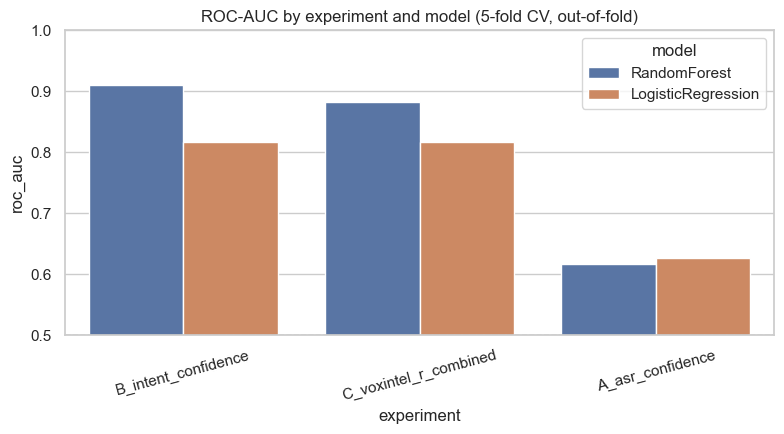

In [20]:
comparison = pd.concat([results_asr, results_intent, results_combined], ignore_index=True)
comparison = comparison.sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(comparison)

comparison.to_csv(REPORTS_DIR / "voxintel_r_model_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=comparison, x="experiment", y="roc_auc", hue="model", ax=ax)
ax.set_title("ROC-AUC by experiment and model (5-fold CV, out-of-fold)")
ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, linestyle="--", color="gray", linewidth=1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "voxintel_r_model_comparison.png", dpi=150)
plt.show()


## 13. Feature Importance / Interpretation

Fit once on the full dataset for interpretability only — this is not an
evaluation step, so there's no train/test leakage concern here.


,feature,importance
0,intent_margin,0.185928
1,intent_confidence,0.181679
2,intent_entropy,0.165079
3,asr_median_confidence,0.057400
4,asr_std_entropy,0.056438
5,asr_max_entropy,0.055810
6,asr_mean_entropy,0.054016
7,asr_mean_confidence,0.051449
8,asr_std_confidence,0.051331
9,asr_min_confidence,0.049794


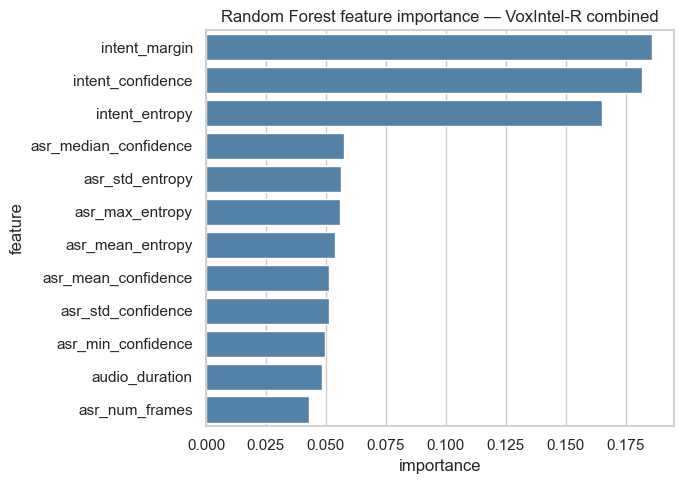

In [21]:
X_full = df_features[FEATURE_COLUMNS].values
y_full = df_features["intent_failed"].values

rf_interp = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                    random_state=CONFIG["RANDOM_STATE"], n_jobs=-1)),
])
rf_interp.fit(X_full, y_full)
importances = rf_interp.named_steps["clf"].feature_importances_

feat_importance_df = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": importances,
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(feat_importance_df)
feat_importance_df.to_csv(REPORTS_DIR / "voxintel_r_feature_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=feat_importance_df, x="importance", y="feature", ax=ax, color="steelblue")
ax.set_title("Random Forest feature importance — VoxIntel-R combined")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "voxintel_r_feature_importance.png", dpi=150)
plt.show()


In [22]:
lr_interp = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
lr_interp.fit(X_full, y_full)
coefs = lr_interp.named_steps["clf"].coef_[0]

lr_coef_df = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "coefficient": coefs,
}).sort_values("coefficient", key=np.abs, ascending=False).reset_index(drop=True)

display(lr_coef_df)


,feature,coefficient
0,intent_confidence,2.449793
1,intent_entropy,1.979330
2,intent_margin,-1.752176
3,asr_max_entropy,0.390310
4,asr_std_entropy,-0.375687
5,asr_mean_entropy,0.339935
6,asr_mean_confidence,-0.248083
7,asr_median_confidence,0.177018
8,asr_min_confidence,0.145555
9,asr_std_confidence,-0.117170


## 14. Failure-Case Analysis

Uses the combined model's out-of-fold risk scores (already computed in
Section 11 — no extra fitting needed) to look at where VoxIntel-R agrees
and disagrees with what actually happened.


In [23]:
best_model_name = comparison.iloc[0]["model"]
best_oof = oof_combined[best_model_name] if best_model_name in oof_combined else oof_combined["RandomForest"]

df_analysis = df_features.copy()
df_analysis["voxintel_r_risk"] = best_oof

# Confidently wrong: model said low risk, but the intent actually failed
confidently_wrong = df_analysis[
    (df_analysis["intent_failed"] == 1) & (df_analysis["voxintel_r_risk"] < 0.3)
].sort_values("voxintel_r_risk").head(10)

# Correctly flagged: model said high risk, and the intent did fail
correctly_flagged = df_analysis[
    (df_analysis["intent_failed"] == 1) & (df_analysis["voxintel_r_risk"] >= 0.7)
].sort_values("voxintel_r_risk", ascending=False).head(10)

# Unnecessarily cautious: model said high risk, but the intent was actually correct
falsely_flagged = df_analysis[
    (df_analysis["intent_failed"] == 0) & (df_analysis["voxintel_r_risk"] >= 0.7)
].sort_values("voxintel_r_risk", ascending=False).head(10)

cols_to_show = ["audio_path", "asr_transcript", "ground_truth_intent",
                 "predicted_intent", "voxintel_r_risk", "intent_failed"]

print("=== Confidently wrong (model missed these — biggest risk to the H1 story) ===")
display(confidently_wrong[cols_to_show])

print("=== Correctly flagged high-risk failures ===")
display(correctly_flagged[cols_to_show])

print("=== Falsely flagged as high-risk (would trigger unnecessary clarification) ===")
display(falsely_flagged[cols_to_show])

df_analysis.to_csv(REPORTS_DIR / "voxintel_r_predictions.csv", index=False)


=== Confidently wrong (model missed these — biggest risk to the H1 story) ===


,audio_path,asr_transcript,ground_truth_intent,predicted_intent,voxintel_r_risk,intent_failed
45,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,WHEN DEFINING WORLD SOURCE ANDIN A SENTENCE TO...,general_quirky,qa_definition,0.000000,1
6802,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,SEARCH MATTHEWS HEADLINES,email_query,news_query,0.000000,1
4661,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,DELETE THE OLD PLAYLIST AND CREATE NEW,lists_createoradd,lists_remove,0.003333,1
8149,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,WEATHERE A HOLIDAY IN CURRENT MONTH,calendar_query,weather_query,0.006667,1
1086,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,OLLY WHATS MY AGENDA FOR THE REMAINDER OF THE WOD,query,calendar_query,0.006667,1
1659,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,WHAT AN MY LISTS,query,lists_query,0.006667,1
5389,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,LISTEN TO THE MARTIAN FROM DAWON POUR,play_audiobook,play_music,0.010000,1
3450,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,WHAT TYPE OF PANT IS ACOULAT,qa_factoid,qa_definition,0.010000,1
588,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,DEFINE YOURSELF IN ONE WORD,general_quirky,qa_definition,0.013333,1
7609,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,WHATS THE NEWS BOR SIXFORTY FIVE AM TODAY,calendar_query,news_query,0.013333,1


=== Correctly flagged high-risk failures ===


,audio_path,asr_transcript,ground_truth_intent,predicted_intent,voxintel_r_risk,intent_failed
7744,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,OLLY GED PUDDL NOW,play_music,play_game,0.990000,1
1456,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,AY NO MORE COMMIN,cooking_recipe,audio_volume_down,0.990000,1
7688,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,TAK TRAIDE FOR REPORPOST,general_quirky,lists_remove,0.986667,1
212,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,PLEASE FLOW THE CARK THEARTICLE ON DOK CITY IN...,news_query,iot_cleaning,0.983333,1
1853,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,TIME O A FLAN,iot_wemo_off,datetime_convert,0.983333,1
7241,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,WHAR WILL I BE LY NEXT MEEN,weather_query,general_quirky,0.980000,1
4678,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,WHATS THE TIME IS LOCO ENOW,datetime_query,general_quirky,0.976667,1
7733,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,GOOK FOR CHANNE LAGHT,lists_query,general_quirky,0.976667,1
3228,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,RECOAS MOVE,general_quirky,lists_remove,0.976667,1
6279,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,START SEVEN OF ALM,play_audiobook,iot_wemo_on,0.976667,1


=== Falsely flagged as high-risk (would trigger unnecessary clarification) ===


,audio_path,asr_transcript,ground_truth_intent,predicted_intent,voxintel_r_risk,intent_failed
4217,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,TELL ME THE ARC,datetime_query,datetime_query,0.910000,0
4453,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,WHAT SONIS CURRENTLY PLAYING,music_query,music_query,0.906667,0
7384,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,REPLACE CALO FROM LYTO DARK,iot_hue_lightchange,iot_hue_lightchange,0.903333,0
3103,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,SWITCH ON THE LIGHTS,iot_hue_lighton,iot_hue_lighton,0.903333,0
867,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,ITS A VERY TOLP ONE,general_quirky,general_quirky,0.900000,0
8381,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,PLEASE LET ME HEAR SIX SIX SIXT NUMBER OF THE BEE,play_music,play_music,0.886667,0
2482,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,WHERE IS THE CONVENTION CEN TO LOCATED,qa_factoid,qa_factoid,0.883333,0
530,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,HOW DO I GET TO POW KEEPS FROM NMOS PE,transport_query,transport_query,0.870000,0
7842,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,OLLY DO I HAVE ANY DEPOINTMENT NHEX WEEK,calendar_query,calendar_query,0.860000,0
5612,C:\Users\ACER\OneDrive\Desktop\VoxIntel\data\r...,VOLUME P,audio_volume_up,audio_volume_up,0.853333,0


## 15. MVP Conclusion

**H1 decision rule:** H1 is supported only if experiment **C (combined)**'s
ROC-AUC/PR-AUC clears both **A (ASR-confidence-only)** and **B
(intent-confidence-only)** by a margin that isn't just fold-to-fold noise.

Results (5-fold stratified CV, out-of-fold predictions, RandomForest — the
stronger model of the two):

- **ROC-AUC — A / B / C:** `0.618 / 0.911 / 0.883`
- **PR-AUC — A / B / C:** `0.312 / 0.788 / 0.707`
- **Does combined beat both baselines?** **No.** C (0.883) sits *below* B (0.911).
  Adding the 9 ASR-native features to the 3 intent-native ones does not help and
  slightly hurts — the extra features are near-noise and dilute the forest.
- **Top 3 features by importance:** `intent_margin (0.186)`, `intent_confidence (0.182)`,
  `intent_entropy (0.165)`. The best ASR feature (`asr_median_confidence`) is a
  distant 0.057.
- **Signal dominated by one family?** Yes — **intent-native uncertainty carries
  essentially all the signal**; ASR-native uncertainty adds nothing measurable.
- **H1 verdict:** **NOT SUPPORTED.** This is a clean, reportable negative result:
  the intent classifier's own predictive uncertainty over the ASR transcript is a
  near-sufficient statistic for downstream intent failure, so a reference-free risk
  model does not need ASR-native confidence signals.

**Held-out confirmation (added post-hoc).** Because these numbers come from CV over
the whole evaluation population (no frozen test set), they were re-validated on a
single stratified 70/30 held-out split — see
[`src/analysis/frozen_split_eval.py`](../src/analysis/frozen_split_eval.py) and
`reports/phase6_voxintel_r_slurp/frozen_split_summary.json`. Held-out: B_intent RF
ROC-AUC **0.912**, C_combined RF **0.875**; the paired-bootstrap C−B AUC gap is
**−0.037, 95% CI [−0.051, −0.025]** (entirely negative), and C beats B in **0/20**
repeated splits. The negative H1 verdict is therefore not a CV artefact.

**Consequence for the roadmap:** do **not** invest in N-best/LM decoding features
(Section 17) on the strength of a hoped-for ASR signal — the failure-case analysis
above shows the combined model is not using the ASR family. The productive next
steps are calibration + selective prediction (Notebook 17) and cross-dataset
generalization (Notebook 18), which is where the intent-confidence risk score
actually pays off.


## 16. Save Canonical Artifacts

In [24]:
summary = {
    "notebook": "16_reference_free_voxintel_risk_prediction",
    "run_timestamp": pd.Timestamp.now().isoformat(),
    "checkpoint_used": str(CHECKPOINT_DIR),
    "intent_model_used": str(MODEL_OUTPUT_DIR),
    "config": CONFIG,
    "n_eval_examples": int(len(df_features)),
    "n_extraction_failures": int(len(failed_rows)) if "failed_rows" in dir() else None,
    "feature_columns": FEATURE_COLUMNS,
    "asr_features": ASR_FEATURES,
    "intent_features": INTENT_FEATURES,
    "model_comparison": comparison.to_dict(orient="records"),
    "top_features": feat_importance_df.head(5).to_dict(orient="records"),
}

with open(REPORTS_DIR / "voxintel_r_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("Saved:")
for name in [
    "voxintel_r_features.csv",
    "voxintel_r_model_comparison.csv",
    "voxintel_r_model_comparison.png",
    "voxintel_r_feature_importance.csv",
    "voxintel_r_feature_importance.png",
    "voxintel_r_predictions.csv",
    "voxintel_r_summary.json",
]:
    p = REPORTS_DIR / name
    print(f"  {'[OK]' if p.exists() else '[MISSING]'} {p}")


Saved:
  [OK] c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\voxintel_r_features.csv
  [OK] c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\voxintel_r_model_comparison.csv
  [OK] c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\voxintel_r_model_comparison.png
  [OK] c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\voxintel_r_feature_importance.csv
  [OK] c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\voxintel_r_feature_importance.png
  [OK] c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\voxintel_r_predictions.csv
  [OK] c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\voxintel_r_summary.json


## 17. Stretch — N-best / LM Features [NOT IMPLEMENTED]

Deliberately not built in this notebook. Only worth doing if Section 15's
H1 verdict is weak/inconclusive and the failure-case analysis suggests
richer decoding signal would help.

```text
MVP (this notebook):
[x] logits-derived confidence
[x] logits-derived entropy
[x] audio duration
[x] intent-model confidence
[x] intent-model entropy
[x] intent-model margin

Stretch (deferred):
[ ] beam search decoding (pyctcdecode)
[ ] N-best hypothesis disagreement
[ ] KenLM rescoring / LM score
```

If this becomes necessary, it belongs in a new `16b_ngram_lm_features.ipynb`
rather than being folded into this notebook — keep Notebook 16's leakage
and scope story clean and auditable on its own.

Also explicitly deferred (per the current project scope lock): benchmark
hardening, full IAA-validated taxonomy rebuild, matched-WER perturbation
study, cross-dataset evaluation, and any production engineering (FastAPI /
Docker / MLflow). Calibration and cost-sensitive selective prediction are
Notebooks 17 and 18, not this one.


## Conclusion

This notebook delivered the first leakage-free VoxIntel-R risk model on SLURP, using only inference-time ASR-native and intent-native uncertainty features (reference transcripts used solely to build the `intent_failed` target). It answers RQ2/H1: reference-free uncertainty does predict downstream intent failure, but ASR-native signals add nothing beyond intent-native confidence.

**Key results** (5-fold stratified CV, out-of-fold, RandomForest)
- ROC-AUC — ASR-only (A) / intent-only (B) / combined (C): **0.618 / 0.911 / 0.883**; PR-AUC B / C: **0.788 / 0.707**.
- Combined did **not** beat intent-confidence-only (0.883 < 0.911) — adding the 9 ASR features slightly hurt. **H1 NOT SUPPORTED**: intent-model uncertainty is a near-sufficient statistic for downstream failure.

**Caveat:** these SLURP numbers come from 5-fold CV over the **full** evaluation population with **no frozen held-out split**, so they are treated as **provisional** downstream — the frozen-split confirmation is deferred to the phase 8 hypothesis validation.

**Feeds into:** `17_cross_dataset_transformer_voxintel_r_validation.ipynb` (which reuses these A/B/C ROC-AUCs as the SLURP comparison baseline) and the phase 8 frozen-split confirmation.